In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [6]:
df=pd.read_csv('fifa21_raw_data.csv')
df.head()

,photoUrl,LongName,playerUrl,Nationality,Positions,Name,Age,↓OVA,POT,Team & Contract,...,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Hits
0,https://cdn.sofifa.com/players/158/023/21_60.png,Lionel Messi,http://sofifa.com/player/158023/lionel-messi/2...,Argentina,RW ST CF,L. Messi,33,93,93,\n\n\n\nFC Barcelona\n2004 ~ 2021\n\n,...,Medium,Low,5 ★,85,92,91,95,38,65,\n372
1,https://cdn.sofifa.com/players/020/801/21_60.png,C. Ronaldo dos Santos Aveiro,http://sofifa.com/player/20801/c-ronaldo-dos-s...,Portugal,ST LW,Cristiano Ronaldo,35,92,92,\n\n\n\nJuventus\n2018 ~ 2022\n\n,...,High,Low,5 ★,89,93,81,89,35,77,\n344
2,https://cdn.sofifa.com/players/200/389/21_60.png,Jan Oblak,http://sofifa.com/player/200389/jan-oblak/210005/,Slovenia,GK,J. Oblak,27,91,93,\n\n\n\nAtlético Madrid\n2014 ~ 2023\n\n,...,Medium,Medium,3 ★,87,92,78,90,52,90,\n86
3,https://cdn.sofifa.com/players/192/985/21_60.png,Kevin De Bruyne,http://sofifa.com/player/192985/kevin-de-bruyn...,Belgium,CAM CM,K. De Bruyne,29,91,91,\n\n\n\nManchester City\n2015 ~ 2023\n\n,...,High,High,4 ★,76,86,93,88,64,78,\n163
4,https://cdn.sofifa.com/players/190/871/21_60.png,Neymar da Silva Santos Jr.,http://sofifa.com/player/190871/neymar-da-silv...,Brazil,LW CAM,Neymar Jr,28,91,91,\n\n\n\nParis Saint-Germain\n2017 ~ 2022\n\n,...,High,Medium,5 ★,91,85,86,94,36,59,\n273


In [7]:
df.shape

(18979, 77)

In [9]:
df.isnull().sum()

photoUrl       0
LongName       0
playerUrl      0
Nationality    0
Positions      0
              ..
PAS            0
DRI            0
DEF            0
PHY            0
Hits           0
Length: 77, dtype: int64

In [10]:
df.columns

Index(['photoUrl', 'LongName', 'playerUrl', 'Nationality', 'Positions', 'Name',
       'Age', '↓OVA', 'POT', 'Team & Contract', 'ID', 'Height', 'Weight',
       'foot', 'BOV', 'BP', 'Growth', 'Joined', 'Loan Date End', 'Value',
       'Wage', 'Release Clause', 'Attacking', 'Crossing', 'Finishing',
       'Heading Accuracy', 'Short Passing', 'Volleys', 'Skill', 'Dribbling',
       'Curve', 'FK Accuracy', 'Long Passing', 'Ball Control', 'Movement',
       'Acceleration', 'Sprint Speed', 'Agility', 'Reactions', 'Balance',
       'Power', 'Shot Power', 'Jumping', 'Stamina', 'Strength', 'Long Shots',
       'Mentality', 'Aggression', 'Interceptions', 'Positioning', 'Vision',
       'Penalties', 'Composure', 'Defending', 'Marking', 'Standing Tackle',
       'Sliding Tackle', 'Goalkeeping', 'GK Diving', 'GK Handling',
       'GK Kicking', 'GK Positioning', 'GK Reflexes', 'Total Stats',
       'Base Stats', 'W/F', 'SM', 'A/W', 'D/W', 'IR', 'PAC', 'SHO', 'PAS',
       'DRI', 'DEF', 'PHY', 'Hits

In [19]:
df['Strength'].head()

0    69
1    78
2    78
3    74
4    50
Name: Strength, dtype: int64

In [18]:
df.rename(columns={'↓OVA':'OVA'},inplace=True)

In [25]:
df_new=df[['ID','Name','Age','Positions','Nationality','OVA','POT','Team & Contract','Value','Wage','Joined','Release Clause','Loan Date End','Acceleration',
           'Strength','Dribbling','Defending'
          ]]
df_new.head()

,ID,Name,Age,Positions,Nationality,OVA,POT,Team & Contract,Value,Wage,Joined,Release Clause,Loan Date End,Acceleration,Strength,Dribbling,Defending
0,158023,L. Messi,33,RW ST CF,Argentina,93,93,\n\n\n\nFC Barcelona\n2004 ~ 2021\n\n,€67.5M,€560K,"Jul 1, 2004",€138.4M,NaN,91,69,96,91
1,20801,Cristiano Ronaldo,35,ST LW,Portugal,92,92,\n\n\n\nJuventus\n2018 ~ 2022\n\n,€46M,€220K,"Jul 10, 2018",€75.9M,NaN,87,78,88,84
2,200389,J. Oblak,27,GK,Slovenia,91,93,\n\n\n\nAtlético Madrid\n2014 ~ 2023\n\n,€75M,€125K,"Jul 16, 2014",€159.4M,NaN,43,78,12,57
3,192985,K. De Bruyne,29,CAM CM,Belgium,91,91,\n\n\n\nManchester City\n2015 ~ 2023\n\n,€87M,€370K,"Aug 30, 2015",€161M,NaN,77,74,88,186
4,190871,Neymar Jr,28,LW CAM,Brazil,91,91,\n\n\n\nParis Saint-Germain\n2017 ~ 2022\n\n,€90M,€270K,"Aug 3, 2017",€166.5M,NaN,94,50,95,94


In [37]:
df_new.columns=df_new.columns.str.lower()
df_new.columns=df_new.columns.str.lower().str.replace(' ','_').str.replace('&','and')
df_new.tail()

,id,name,age,positions,nationality,ova,pot,team_and_contract,value,wage,joined,release_clause,loan_date_end,acceleration,strength,dribbling,defending
18974,257710,Zhang Mengxuan,21,CB,China PR,47,52,\n\n\n\nChongqing Dangdai Lifan FC SWM Team\n2...,€35K,€1K,"Aug 1, 2020",€57K,NaN,60,45,19,148
18975,258736,V. Da Silva,17,ST,England,47,67,\n\n\n\nOldham Athletic\n2020 ~ 2021\n\n,€60K,€500,"Aug 1, 2020",€165K,NaN,69,35,53,42
18976,247223,Xia Ao,21,CB,China PR,47,55,\n\n\n\nWuhan Zall\n2018 ~ 2022\n\n,€40K,€1K,"Jul 13, 2018",€70K,NaN,68,50,27,147
18977,258760,B. Hough,17,CM,England,47,67,\n\n\n\nOldham Athletic\n2020 ~ 2021\n\n,€60K,€500,"Aug 1, 2020",€165K,NaN,63,47,46,116
18978,255958,M. Flores,19,CDM,Bolivia,47,63,\n\n\n\nClub Bolívar\n2020 ~ 2024\n\n,€60K,€500,"Jan 1, 2020",€167K,NaN,55,47,45,129


In [38]:
df_new['team_and_contract'].str.strip()

0                               FC Barcelona\n2004 ~ 2021
1                                   Juventus\n2018 ~ 2022
2                            Atlético Madrid\n2014 ~ 2023
3                            Manchester City\n2015 ~ 2023
4                        Paris Saint-Germain\n2017 ~ 2022
                               ...                       
18974    Chongqing Dangdai Lifan FC SWM Team\n2020 ~ 2020
18975                        Oldham Athletic\n2020 ~ 2021
18976                             Wuhan Zall\n2018 ~ 2022
18977                        Oldham Athletic\n2020 ~ 2021
18978                           Club Bolívar\n2020 ~ 2024
Name: team_and_contract, Length: 18979, dtype: object

In [42]:
df_new[['team','contract']]=df_new['team_and_contract'].str.strip().str.split('\n',n=1,expand=True)
df_new[['team','contract']].head()

,team,contract
0,FC Barcelona,2004 ~ 2021
1,Juventus,2018 ~ 2022
2,Atlético Madrid,2014 ~ 2023
3,Manchester City,2015 ~ 2023
4,Paris Saint-Germain,2017 ~ 2022


In [45]:
df_new[['contract_start','contract_end']]=df_new['contract'].str.strip().str.split('~',n=1,expand=True)
df_new[['contract_start','contract_end']].head()

,contract_start,contract_end
0,2004,2021
1,2018,2022
2,2014,2023
3,2015,2023
4,2017,2022


In [46]:
df_new.shape

(18979, 21)

In [47]:
df_new.columns

Index(['id', 'name', 'age', 'positions', 'nationality', 'ova', 'pot',
       'team_and_contract', 'value', 'wage', 'joined', 'release_clause',
       'loan_date_end', 'acceleration', 'strength', 'dribbling', 'defending',
       'team', 'contract', 'contract_start', 'contract_end'],
      dtype='object')

In [49]:
df_new[['team_and_contract','team','contract','contract_start','contract_end']].head()

,team_and_contract,team,contract,contract_start,contract_end
0,\n\n\n\nFC Barcelona\n2004 ~ 2021\n\n,FC Barcelona,2004 ~ 2021,2004,2021
1,\n\n\n\nJuventus\n2018 ~ 2022\n\n,Juventus,2018 ~ 2022,2018,2022
2,\n\n\n\nAtlético Madrid\n2014 ~ 2023\n\n,Atlético Madrid,2014 ~ 2023,2014,2023
3,\n\n\n\nManchester City\n2015 ~ 2023\n\n,Manchester City,2015 ~ 2023,2015,2023
4,\n\n\n\nParis Saint-Germain\n2017 ~ 2022\n\n,Paris Saint-Germain,2017 ~ 2022,2017,2022


In [50]:
df_new.drop(columns=['team_and_contract','contract'],inplace=True)

In [51]:
df_new.shape

(18979, 19)

In [58]:
df_new['age'].unique

<bound method Series.unique of 0        33
1        35
2        27
3        29
4        28
         ..
18974    21
18975    17
18976    21
18977    17
18978    19
Name: age, Length: 18979, dtype: int64>


In [70]:
df_new['age_group']=pd.cut(df_new['age'],
                bins=[0,20,30,40,60],
                  labels=['U-20','U-30','U-40','U-60']    
)

name           �. Vlădoiu
age                    53
age_group            U-60
nationality      Zimbabwe
dtype: object

In [73]:
df_new['loan_status']=np.where(
                            df_new['loan_date_end'].isna(),'Not on Loan','On Loan'
)

In [83]:
df_new.head()

,id,name,age,positions,nationality,ova,pot,value,wage,joined,...,acceleration,strength,dribbling,defending,team,contract_start,contract_end,age_group,is_player_on_loan,loan_status
0,158023,L. Messi,33,RW ST CF,Argentina,93,93,€67.5M,€560K,"Jul 1, 2004",...,91,69,96,91,FC Barcelona,2004,2021,U-40,Not on Loan,Not on Loan
1,20801,Cristiano Ronaldo,35,ST LW,Portugal,92,92,€46M,€220K,"Jul 10, 2018",...,87,78,88,84,Juventus,2018,2022,U-40,Not on Loan,Not on Loan
2,200389,J. Oblak,27,GK,Slovenia,91,93,€75M,€125K,"Jul 16, 2014",...,43,78,12,57,Atlético Madrid,2014,2023,U-30,Not on Loan,Not on Loan
3,192985,K. De Bruyne,29,CAM CM,Belgium,91,91,€87M,€370K,"Aug 30, 2015",...,77,74,88,186,Manchester City,2015,2023,U-30,Not on Loan,Not on Loan
4,190871,Neymar Jr,28,LW CAM,Brazil,91,91,€90M,€270K,"Aug 3, 2017",...,94,50,95,94,Paris Saint-Germain,2017,2022,U-30,Not on Loan,Not on Loan


0    0
1    0
2    2
3    0
4    0
Name: possible_growth, dtype: int64

In [89]:
df_new.columns

Index(['id', 'name', 'age', 'positions', 'nationality', 'ova', 'pot', 'value',
       'wage', 'joined', 'release_clause', 'loan_date_end', 'acceleration',
       'strength', 'dribbling', 'defending', 'team', 'contract_start',
       'contract_end', 'age_group', 'is_player_on_loan', 'loan_status',
       'possible_growth'],
      dtype='object')

In [108]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18979 entries, 0 to 18978
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   id                 18979 non-null  int64   
 1   name               18979 non-null  object  
 2   age                18979 non-null  int64   
 3   positions          18979 non-null  object  
 4   nationality        18979 non-null  object  
 5   ova                18979 non-null  int64   
 6   pot                18979 non-null  int64   
 7   value              18979 non-null  object  
 8   wage               18979 non-null  object  
 9   joined             18979 non-null  object  
 10  release_clause     18979 non-null  object  
 11  loan_date_end      1013 non-null   object  
 12  acceleration       18979 non-null  int64   
 13  strength           18979 non-null  int64   
 14  dribbling          18979 non-null  int64   
 15  defending          18979 non-null  int64   
 16  team

In [114]:
df_new[['name','value']].head()

,name,value
0,L. Messi,€67.5M
1,Cristiano Ronaldo,€46M
2,J. Oblak,€75M
3,K. De Bruyne,€87M
4,Neymar Jr,€90M


In [119]:
def convertvalue(x):
    x=str(x).replace('€','')

    if 'M' in x:
        return float(x.replace('M',''))*1000000
    elif 'K' in x:
        return float(x.replace('K',''))*1000
    else:
        return float(x)
df_new['value']=df_new['value'].apply(convertvalue)
df_new['wage']=df_new['wage'].apply(convertvalue)

In [120]:
df_new[['name','value']].head()

,name,value
0,L. Messi,67500000.0
1,Cristiano Ronaldo,46000000.0
2,J. Oblak,75000000.0
3,K. De Bruyne,87000000.0
4,Neymar Jr,90000000.0


In [121]:
# 1 average value per player
avpp=df_new['value'].mean()
round(avpp,2)

np.float64(2228953.21)

In [124]:
# 2 average pay per hour
awph=df_new['wage'].mean()
round(awph,2)

np.float64(8796.129933083936)

In [145]:
# 3 average wage by nationality
awbn=df_new.groupby('nationality')['wage'].mean().sort_values(ascending=False).head(5).reset_index()
awbn

,nationality,wage
0,Tanzania,60000.000000
1,Bermuda,33000.000000
2,Saint Kitts and Nevis,30500.000000
3,Dominican Republic,23083.333333
4,Gabon,22984.375000


In [133]:
# 4 top 5 positions
top_positions=df_new.groupby('positions')['value'].mean().sort_values(ascending=False).reset_index().head()
top_positions

,positions,value
0,RW CAM CM,60000000.0
1,LM RW LW,30500000.0
2,CAM RM CF,30000000.0
3,CM RM ST,27500000.0
4,ST RM CF,27000000.0


In [143]:
# 5 top 5 players  in terms of value

top_5_player=df_new.nlargest(5,'value')[['name','wage','value']]
top_5_player

,name,wage,value
6,K. Mbappé,160000.0,105500000.0
4,Neymar Jr,270000.0,90000000.0
3,K. De Bruyne,370000.0,87000000.0
5,R. Lewandowski,240000.0,80000000.0
8,M. Salah,250000.0,78000000.0


In [153]:
#df_new.head()
#team_analysis 
team_analysis=df_new.groupby('team').agg(total_value=('value','sum'),avg_value=('value','mean'),player=('name','count')).sort_values(by='total_value', ascending=False).head().reset_index()
team_analysis

,team,total_value,avg_value,player
0,Liverpool,820435000.0,2.486167e+07,33
1,Manchester City,753425000.0,2.283106e+07,33
2,Real Madrid,749075000.0,2.496917e+07,30
3,Paris Saint-Germain,647125000.0,2.157083e+07,30
4,FC Bayern München,647000000.0,2.813043e+07,23


In [157]:
# 6 loan rate by team
loan_rate=df_new.groupby('team')['loan_status'].apply(lambda x:(x=='On Loan').mean()*100).sort_values(ascending=False).head(5).reset_index()
loan_rate

,team,loan_status
0,Sangju Sangmu FC,71.428571
1,Royal Excel Mouscron,35.714286
2,FC Cartagena,30.000000
3,CD Mirandés,30.000000
4,Hellas Verona,28.125000


In [161]:
# 7 top players by ova (current best player)

overall_top_players=df_new.nlargest(5,'ova')[['name','nationality','team','ova']]
overall_top_players

,name,nationality,team,ova
0,L. Messi,Argentina,FC Barcelona,93
1,Cristiano Ronaldo,Portugal,Juventus,92
2,J. Oblak,Slovenia,Atlético Madrid,91
3,K. De Bruyne,Belgium,Manchester City,91
4,Neymar Jr,Brazil,Paris Saint-Germain,91


In [163]:
# 8 will be great player
potential_top_player=df_new.nlargest(5,'pot')[['name','nationality','team','pot']]
potential_top_player

,name,nationality,team,pot
6,K. Mbappé,France,Paris Saint-Germain,95
0,L. Messi,Argentina,FC Barcelona,93
2,J. Oblak,Slovenia,Atlético Madrid,93
11,M. ter Stegen,Germany,FC Barcelona,93
28,J. Sancho,England,Borussia Dortmund,93


In [186]:
# 9 high growth players
#df_new['potential_growth']=df_new['pot']-df_new['ova']
grow=df_new.nlargest(5,'potential_growth')[['name','nationality','team','age','ova','pot','potential_growth']]
grow

,name,nationality,team,age,ova,pot,potential_growth
14827,B. Arrey-Mbi,Germany,Bayern München II,17,60,86,26
17874,R. Richards,England,West Bromwich Albion,16,54,80,26
18121,A. Hajdari,Switzerland,FC Basel 1893,17,53,79,26
15983,C. Riad,Morocco,CE Sabadell FC,17,59,84,25
16289,O. Babuscu,Austria,FC Admira Wacker Mödling,16,58,83,25


In [188]:
# 10 relationship between player ova and player value
correlation=df_new[['ova','pot','value','potential_growth']].corr()
correlation

,ova,pot,value,potential_growth
ova,1.000000,0.632130,0.631544,-0.548035
pot,0.632130,1.000000,0.568367,0.301709
value,0.631544,0.568367,1.000000,-0.163514
potential_growth,-0.548035,0.301709,-0.163514,1.000000


In [190]:
df_new.columns

Index(['id', 'name', 'age', 'positions', 'nationality', 'ova', 'pot', 'value',
       'wage', 'joined', 'release_clause', 'loan_date_end', 'acceleration',
       'strength', 'dribbling', 'defending', 'team', 'contract_start',
       'contract_end', 'age_group', 'is_player_on_loan', 'loan_status',
       'possible_growth', 'potential_growth'],
      dtype='object')

In [211]:
# average acceleration by position
aap=df_new.groupby('positions').agg(
acceleration=('acceleration','mean'),
srength=('strength','mean'),
dribble=('dribbling','mean'),
defending=('defending','mean')).sort_values(by='defending',ascending=False).head()
aap

,acceleration,srength,dribble,defending
positions,,,,
RB CDM CM,68.5,70.5,72.5,233.5
CM RM ST,79.0,81.0,82.0,233.0
LM RB LB,75.0,65.0,80.0,230.0
CB RB RM,74.0,71.0,72.0,229.5
LWB LW LB,67.0,71.0,73.0,224.0


In [222]:
(df_new['loan_status']==df_new['is_player_on_loan']).all()

np.True_

In [223]:
df_new.drop(columns=['is_player_on_loan'],inplace=True)
df_new.columns

Index(['id', 'name', 'age', 'positions', 'nationality', 'ova', 'pot', 'value',
       'wage', 'joined', 'release_clause', 'loan_date_end', 'acceleration',
       'strength', 'dribbling', 'defending', 'team', 'contract_start',
       'contract_end', 'age_group', 'loan_status', 'possible_growth',
       'potential_growth'],
      dtype='object')

In [226]:
df_new.drop(columns=['possible_growth'],inplace=True)

In [ ]:
# data visualisation using pyplot

In [227]:
df_visual=df_new.copy()

In [228]:
df_visual.head()

,id,name,age,positions,nationality,ova,pot,value,wage,joined,...,acceleration,strength,dribbling,defending,team,contract_start,contract_end,age_group,loan_status,potential_growth
0,158023,L. Messi,33,RW ST CF,Argentina,93,93,67500000.0,560000.0,"Jul 1, 2004",...,91,69,96,91,FC Barcelona,2004,2021,U-40,Not on Loan,0
1,20801,Cristiano Ronaldo,35,ST LW,Portugal,92,92,46000000.0,220000.0,"Jul 10, 2018",...,87,78,88,84,Juventus,2018,2022,U-40,Not on Loan,0
2,200389,J. Oblak,27,GK,Slovenia,91,93,75000000.0,125000.0,"Jul 16, 2014",...,43,78,12,57,Atlético Madrid,2014,2023,U-30,Not on Loan,2
3,192985,K. De Bruyne,29,CAM CM,Belgium,91,91,87000000.0,370000.0,"Aug 30, 2015",...,77,74,88,186,Manchester City,2015,2023,U-30,Not on Loan,0
4,190871,Neymar Jr,28,LW CAM,Brazil,91,91,90000000.0,270000.0,"Aug 3, 2017",...,94,50,95,94,Paris Saint-Germain,2017,2022,U-30,Not on Loan,0


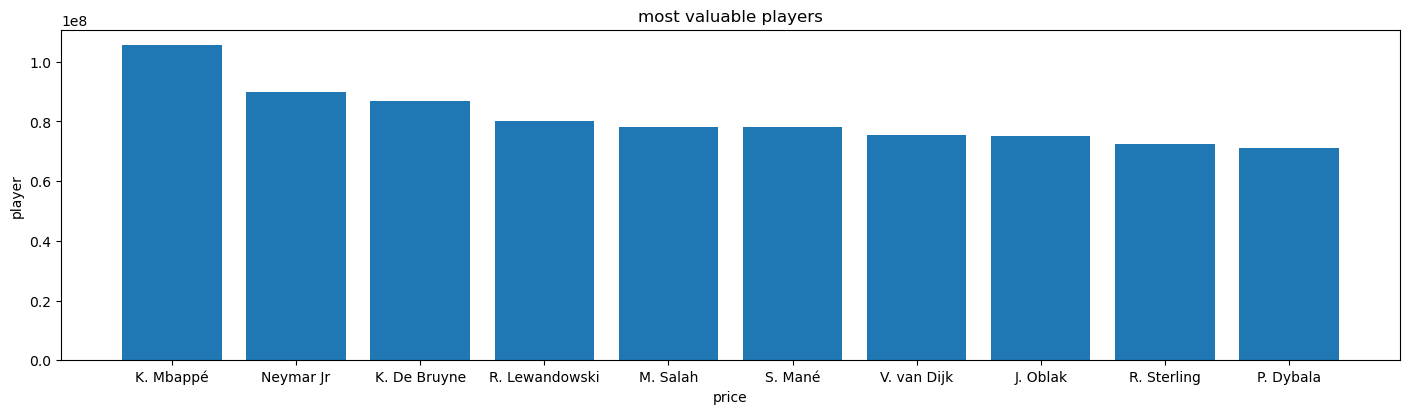

In [235]:
# 10 most valuable player

top_player=df_visual.nlargest(10,'value')
plt.figure(figsize=(14,4))
plt.bar(top_player['name'],top_player['value'])

plt.tight_layout()
plt.title('most valuable players')
plt.xlabel('price')
plt.ylabel('player')
plt.show()

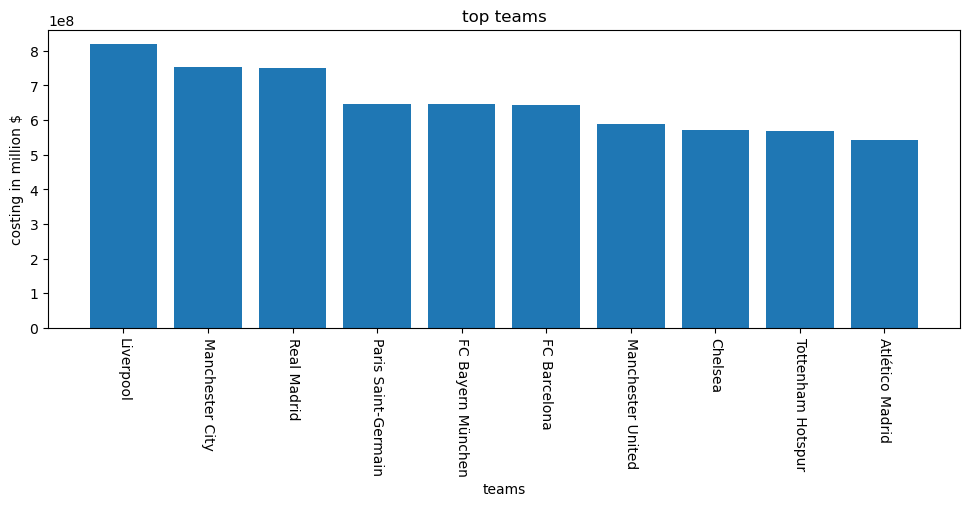

In [244]:
# top 10 teams by their squad
top_team=df_visual.groupby('team')['value'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,4))
plt.xticks(rotation=-90)
plt.xlabel('teams')
plt.ylabel('costing in million $')
plt.title('top teams')
plt.tight_layout()
plt.bar(top_team.index,top_team.values)
plt.show()

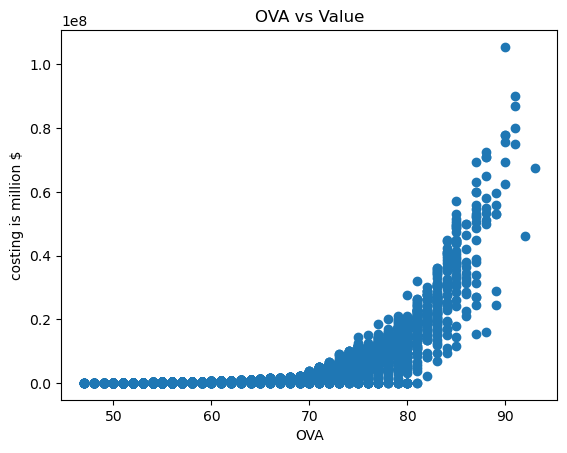

In [251]:
plt.scatter(df_visual['ova'],df_visual['value'])
plt.title('OVA vs Value')
plt.xlabel('OVA')
plt.ylabel('costing is million $')
plt.show()

(array([2.097e+03, 5.674e+03, 5.165e+03, 3.245e+03, 2.227e+03, 5.170e+02,
        4.600e+01, 7.000e+00, 0.000e+00, 1.000e+00]),
 array([16. , 19.7, 23.4, 27.1, 30.8, 34.5, 38.2, 41.9, 45.6, 49.3, 53. ]),
 <BarContainer object of 10 artists>)

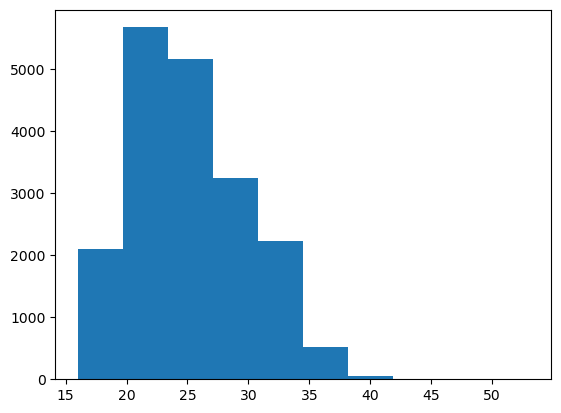

In [266]:
plt.hist(df_visual['age'],bins=10)

([<matplotlib.patches.Wedge at 0x1eea9fd8f50>,
 [Text(-1.0845717839727138, 0.18358661555310982, 'Not on Loan'),
  Text(1.0845718000223619, -0.18358652073682866, 'On Loan')],
 [Text(-0.591584609439662, 0.1001381539380599, '95%'),
  Text(0.5915846181940155, -0.10013810222008834, '5%')])

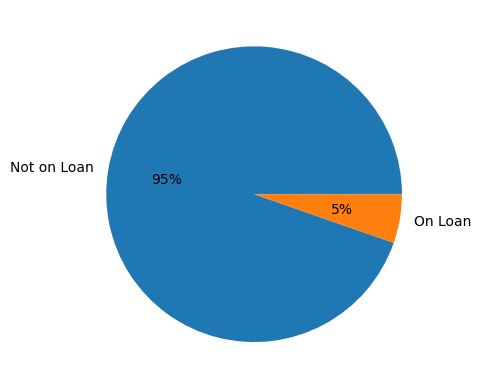

In [271]:
loan_counts=df_visual['loan_status'].value_counts()
plt.pie(loan_counts.values,labels=loan_counts.index,autopct='%1.0f%%')

<Axes: >

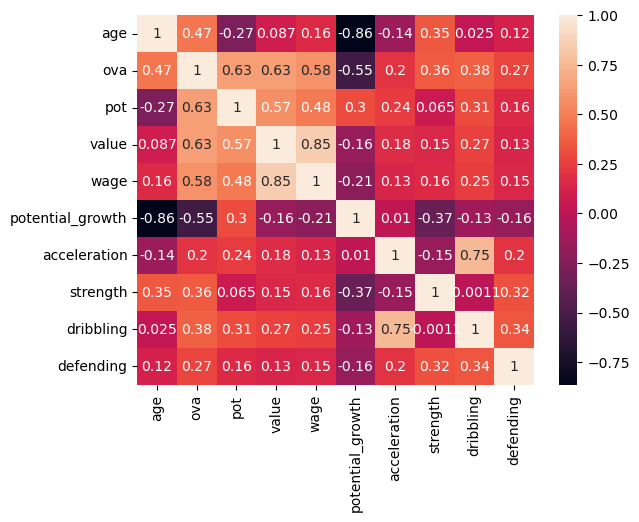

In [279]:


col_visual=df_visual[['age','ova','pot','value','wage','potential_growth','acceleration','strength','dribbling','defending']]
sns.heatmap(col_visual.corr(),annot=True)

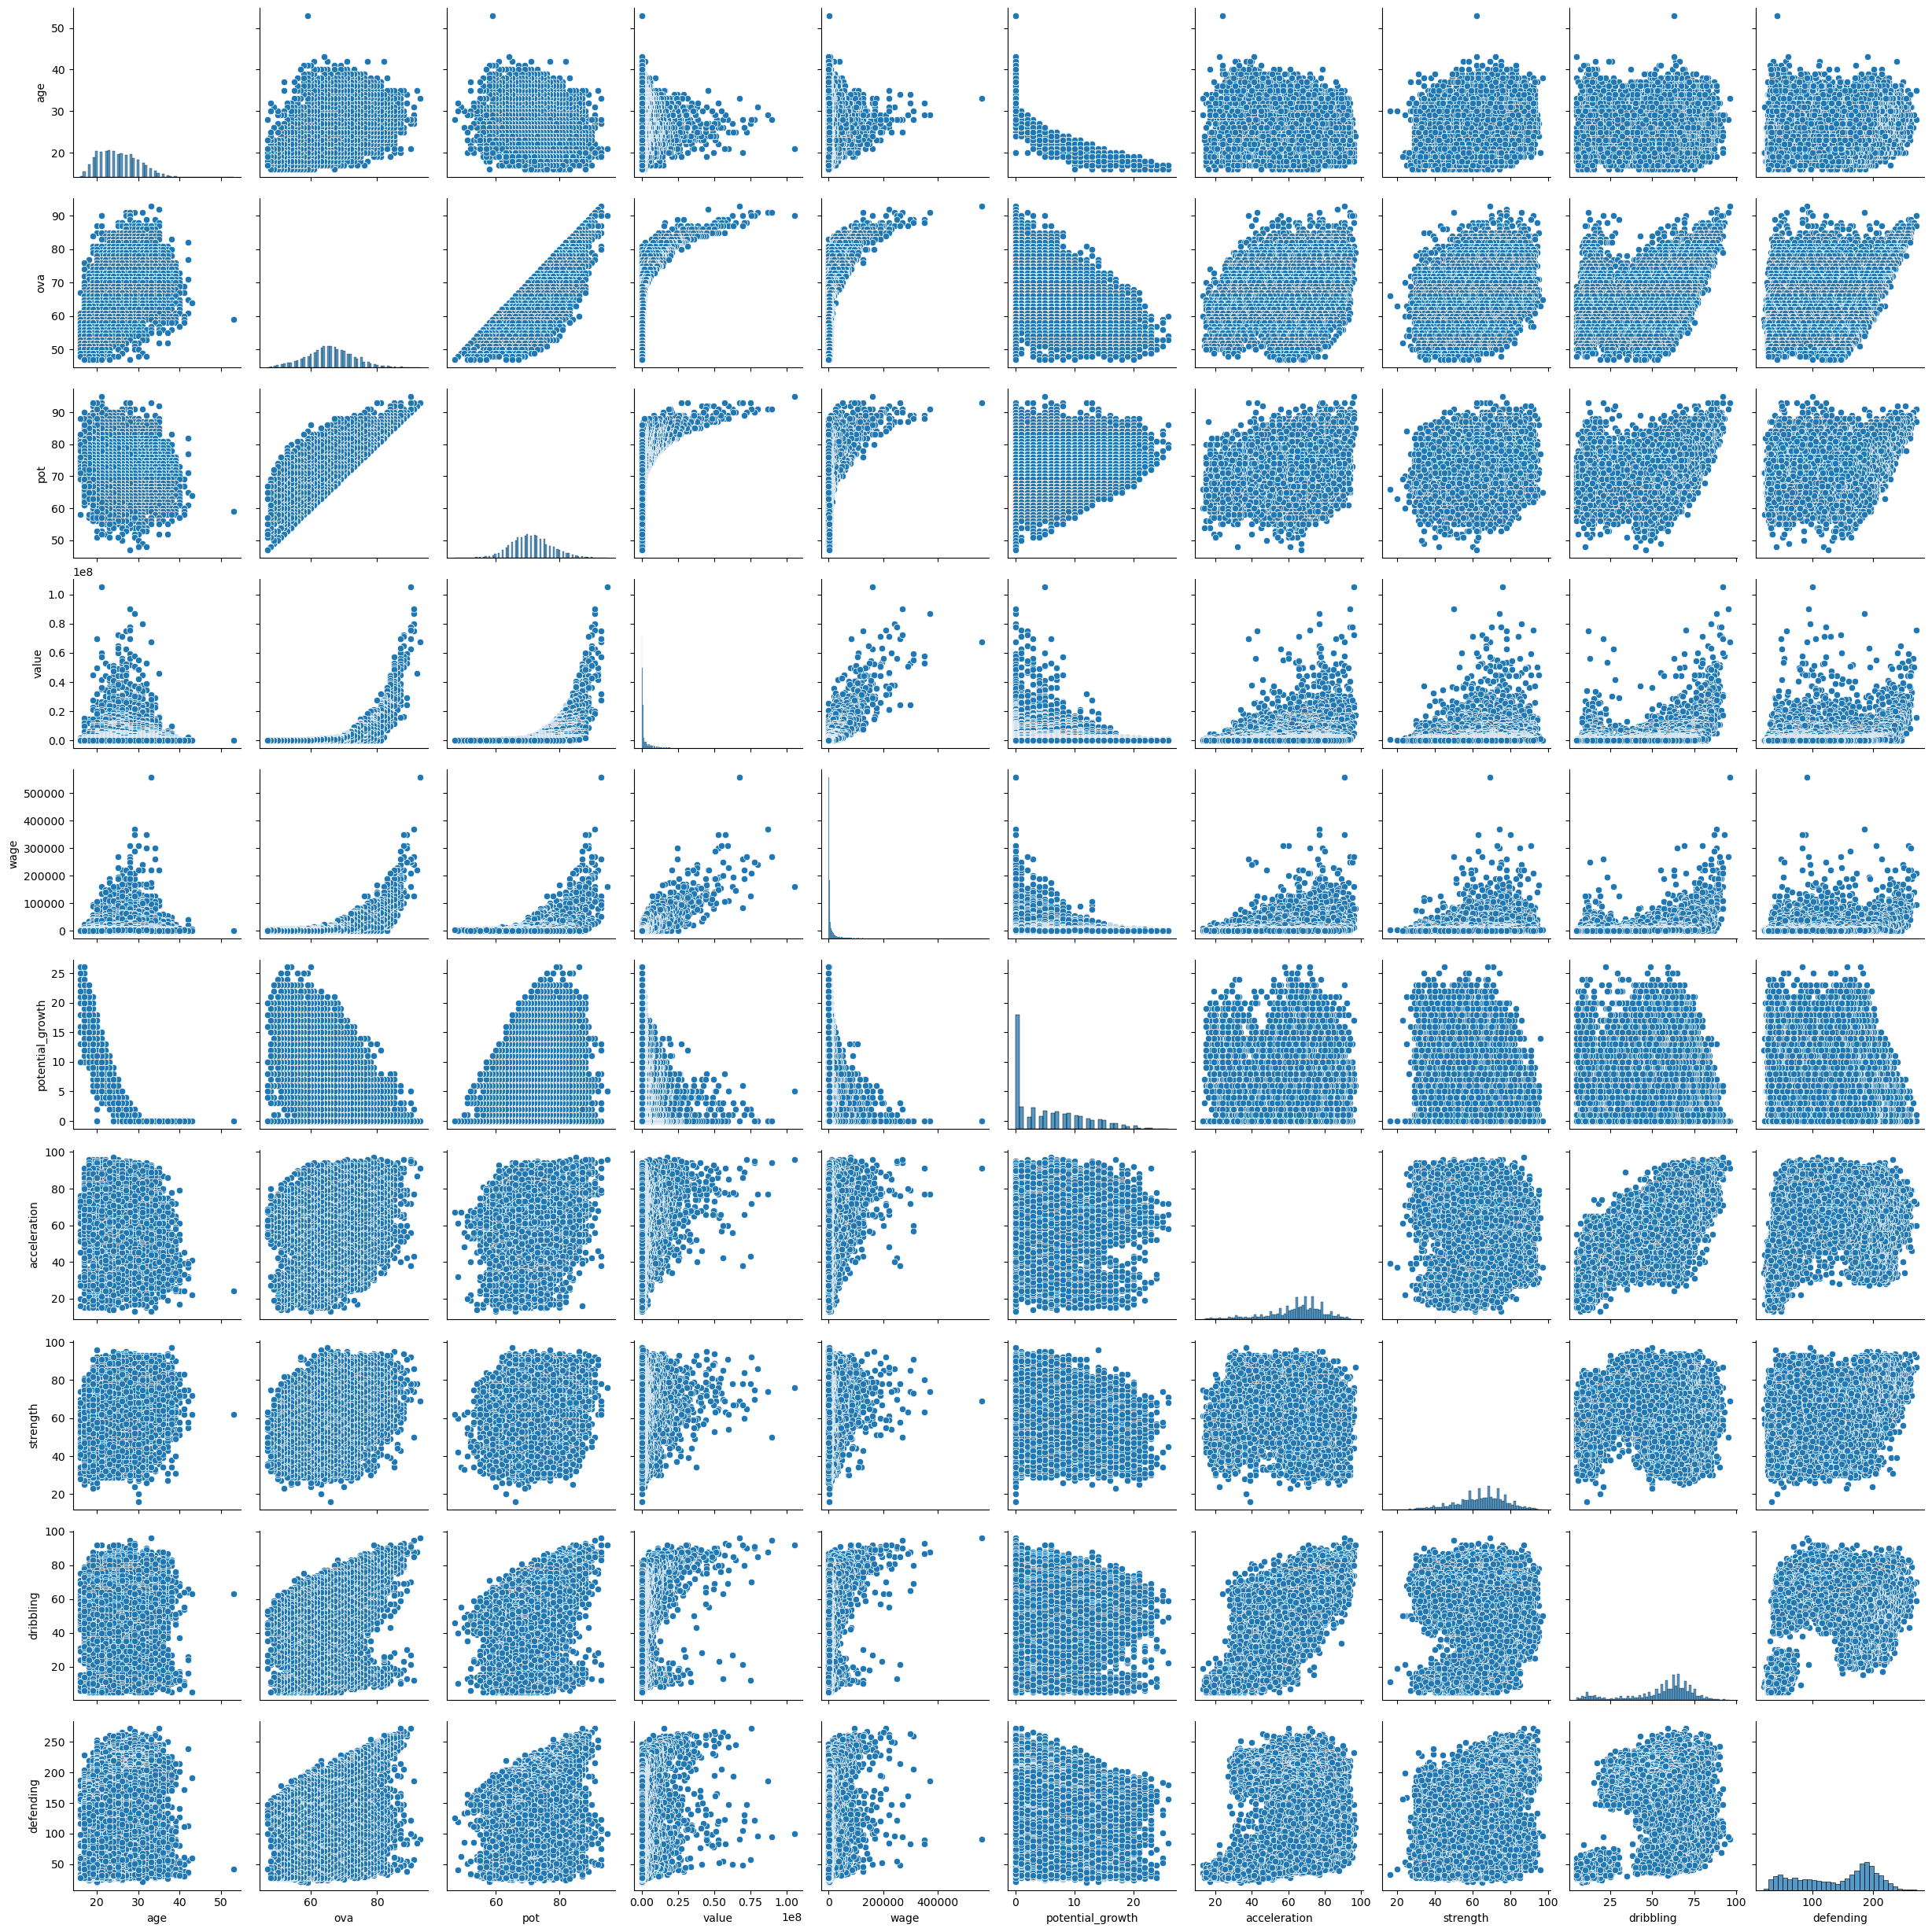

In [280]:
sns.pairplot(col_visual)